Optimized model parameters:
Theta_(D/E)=439.941057
beta_1=0.009053
beta_2=0.025656
tau=1688.376623
gamma=33.049587
RSE: 0.6207 J/mol/K


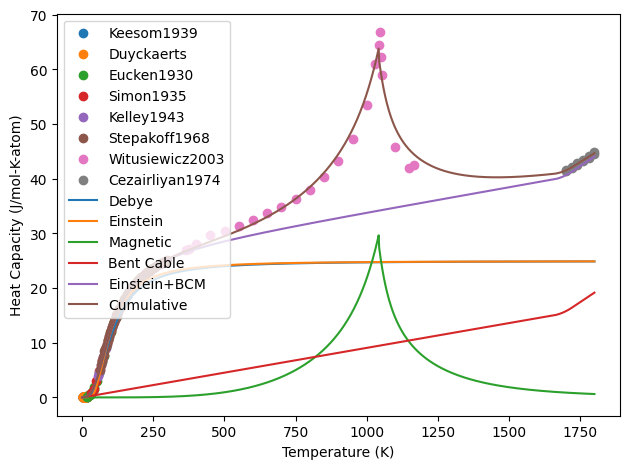

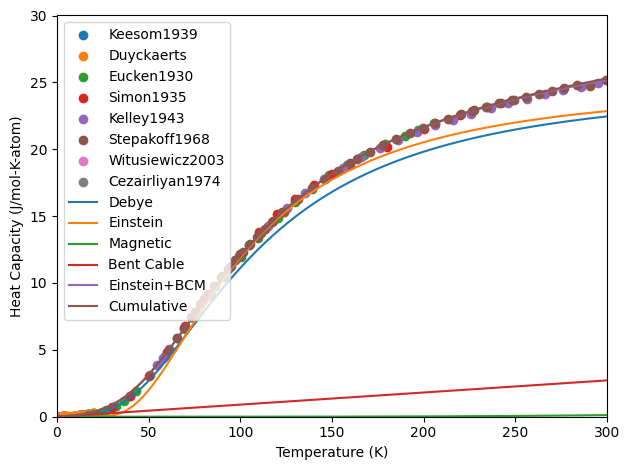

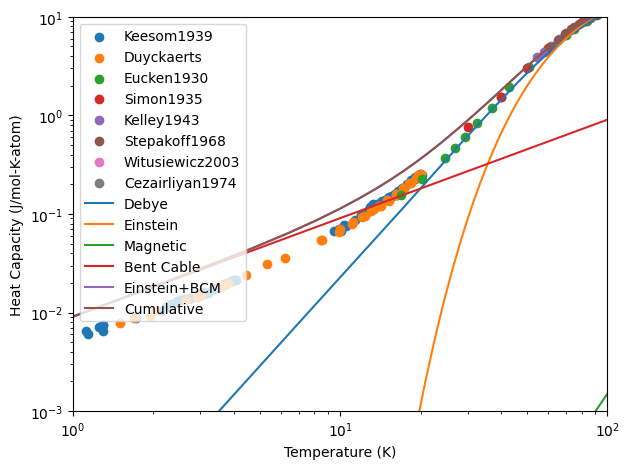

In [1]:
from libreCalphad.models.segmented_regression import _bent_cable_Cp, _debye_Cp, _einstein_Cp, _holzapfel_debye_Cp, _xiong_Cp, segmented_regression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

R = 8.314472
# magnetic model constants
beta_Fe = 2.22  # magnetic moment per atom Fe
struct_fact_bcc = 0.37
Tc_Fe = 1043  # K, Curie temperature for Fe
theta_Fe = 309  # K, Einstein temperature from Chen & Sundman
sr_df, min_fits = segmented_regression("/home/matt/opt/ESPEI-datasets/datasets", ["FE", "VA"], "BCC_A2")
# initialize a dataframe for the model
df_model = pd.DataFrame()
df_model["temperature"] = np.linspace(1, np.max(sr_df["temperature"]), num=1000)

print("Optimized model parameters:")
print(f"Theta_(D/E)={min_fits.x[0]:4f}")
print(f"beta_1={min_fits.x[1]:3f}")
print(f"beta_2={min_fits.x[2]:3f}")
print(f"tau={min_fits.x[3]:3f}")
print(f"gamma={min_fits.x[4]:3f}")
print(f"RSE: {min_fits.fun:.4f} J/mol/K")

# prepare arrays for plotting
df_model["debye_model"] = _holzapfel_debye_Cp(df_model["temperature"], *min_fits.x[:1])
df_model["einstein_model"] = _einstein_Cp(df_model["temperature"], theta_Fe)
df_model["magnetic_model"] = _xiong_Cp(
    df_model["temperature"], beta_Fe, struct_fact_bcc, Tc_Fe
)
df_model["bent_cable_model"] = _bent_cable_Cp(df_model["temperature"], *min_fits.x[1:])
df_model["cumulative_model"] = (
    df_model["debye_model"]
    + df_model["magnetic_model"]
    + df_model["bent_cable_model"]
)

fig, ax = plt.subplots()
for reference in sr_df["reference"].unique():
    sr_sub = sr_df.query("reference == @reference")
    ax.scatter(sr_sub["temperature"], sr_sub["Cp"], label=reference)
ax.plot(df_model["temperature"], df_model["debye_model"], label="Debye")
ax.plot(df_model["temperature"], df_model["einstein_model"], label="Einstein")
ax.plot(df_model["temperature"], df_model["magnetic_model"], label="Magnetic")
ax.plot(df_model["temperature"], df_model["bent_cable_model"], label="Bent Cable")
ax.plot(
    df_model["temperature"],
    df_model["debye_model"] + df_model["bent_cable_model"],
    label="Einstein+BCM",
)
ax.plot(df_model["temperature"], df_model["cumulative_model"], label="Cumulative")
ax.legend()

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Heat Capacity (J/mol-K-atom)")
fig.tight_layout()

# < 300 K
fig, ax = plt.subplots()
for reference in sr_df["reference"].unique():
    sr_sub = sr_df.query("reference == @reference")
    ax.scatter(sr_sub["temperature"], sr_sub["Cp"], label=reference)
ax.plot(df_model["temperature"], df_model["debye_model"], label="Debye")
ax.plot(df_model["temperature"], df_model["einstein_model"], label="Einstein")
ax.plot(df_model["temperature"], df_model["magnetic_model"], label="Magnetic")
ax.plot(df_model["temperature"], df_model["bent_cable_model"], label="Bent Cable")
ax.plot(
    df_model["temperature"],
    df_model["debye_model"] + df_model["bent_cable_model"],
    label="Einstein+BCM",
)
ax.plot(df_model["temperature"], df_model["cumulative_model"], label="Cumulative")
ax.legend()

ax.set_xlim((0, 300))
ax.set_xlabel("Temperature (K)")
ax.set_ylim((0, 30))
ax.set_ylabel("Heat Capacity (J/mol-K-atom)")
fig.tight_layout()

# Close to 0 K
fig, ax = plt.subplots()
for reference in sr_df["reference"].unique():
    sr_sub = sr_df.query("reference == @reference")
    ax.scatter(sr_sub["temperature"], sr_sub["Cp"], label=reference)
ax.plot(df_model["temperature"], df_model["debye_model"], label="Debye")
ax.plot(df_model["temperature"], df_model["einstein_model"], label="Einstein")
ax.plot(df_model["temperature"], df_model["magnetic_model"], label="Magnetic")
ax.plot(df_model["temperature"], df_model["bent_cable_model"], label="Bent Cable")
ax.plot(
    df_model["temperature"],
    df_model["debye_model"] + df_model["bent_cable_model"],
    label="Einstein+BCM",
)
ax.plot(df_model["temperature"], df_model["cumulative_model"], label="Cumulative")
ax.legend()

ax.set_xlim((1e0, 1e2))
ax.set_xscale("log")
ax.set_xlabel("Temperature (K)")
ax.set_ylim((1e-3, 1e1))
ax.set_yscale("log")
ax.set_ylabel("Heat Capacity (J/mol-K-atom)")
fig.tight_layout()

np.float64(2130.1861999969437)

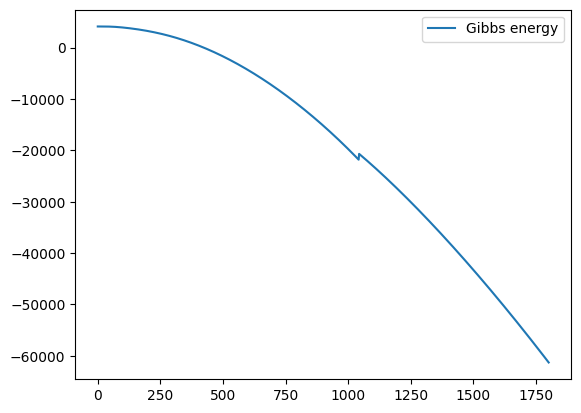

In [3]:
from libreCalphad.models.segmented_regression import calc_enthalpy, calc_entropy, calc_gibbs_energy, _xiong_enthalpy, _bent_cable_enthalpy
import matplotlib.pyplot as plt

xiong_params = [beta_Fe, struct_fact_bcc, Tc_Fe]
# enthalpy = calc_enthalpy(df_model["temperature"], min_fits, xiong_params=xiong_params)
# xiong_enthalpy = _xiong_enthalpy(df_model["temperature"], *xiong_params)
# bc_enthalpy = _bent_cable_enthalpy(df_model["temperature"], *min_fits.x[1:])
# entropy = calc_entropy(df_model["temperature"], min_fits, xiong_params=xiong_params)
gibbs = calc_gibbs_energy(df_model["temperature"], min_fits, xiong_params=xiong_params)

fig, ax = plt.subplots()
# ax.plot(enthalpy, label="enthalpy")
# ax.plot(xiong_enthalpy, label="xiong")
# ax.plot(bc_enthalpy, label="bent cable")
# ax.plot(entropy, label="entropy")
ax.plot(df_model["temperature"], gibbs, label="Gibbs energy")
ax.legend()
calc_gibbs_energy(298.15, min_fits, xiong_params=xiong_params)